# Récupération données météo sur les communes francaises

In [1]:
# Import de données
import geopandas as gpd
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

## Récupération des centroides des communes

In [8]:
commune_path = "../../data/raw/ADE_4-0_GPKG_WGS84G_FRA-ED2026-02-16.gpkg"

In [9]:
# Récupération des centroids de communes
communes = gpd.read_file(commune_path, layer="COMMUNE")
communes.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
# Calculer les centroïdes (en LAMB93 pour que les distances en metres soient correctes)
communes["centroid"] = communes.to_crs(epsg=2154).geometry.centroid

In [11]:
# Extraire lat/lon en WGS84
communes["longitude"] = communes.geometry.centroid.to_crs(epsg=4326).x
communes["latitude"]  = communes.geometry.centroid.to_crs(epsg=4326).y

/tmp/ipykernel_23457/3527976916.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  communes["longitude"] = communes.geometry.centroid.to_crs(epsg=4326).x
/tmp/ipykernel_23457/3527976916.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  communes["latitude"]  = communes.geometry.centroid.to_crs(epsg=4326).y


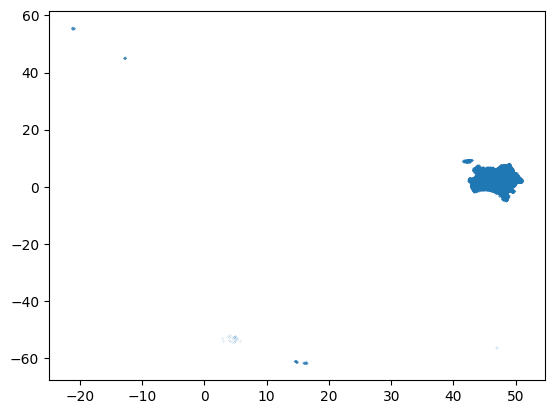

In [12]:
plt.scatter(communes["latitude"], communes["longitude"], s=0.01)

## Connectionà l'API météo

In [13]:
# Dates
jour = datetime.today()
annee = jour.year

In [25]:
# Centroids pour une commune donné
nom_commune = "BOURGUEIL"

query = "nom_officiel_en_majuscules == @nom_commune"
lat = communes.query(query)["latitude"].values[0]
long = communes.query(query)["longitude"].values[0]

In [26]:
print(lat, long)

47.30954810819346 0.1747534514258095


In [27]:
# URL de recupération
meteo_url_archives = "https://archive-api.open-meteo.com/v1/archive"  # ← archive → forecast
meteo_url_futur = "https://api.open-meteo.com/v1/meteofrance"  # ← archive → forecast

In [28]:
# Dates de récupération
start_date = f"{annee}-01-01"
end_date =  jour.strftime("%Y-%m-%d") if annee == jour.year else f"{annee}-12-31"

In [29]:
# Setup de récupération des données
hourly_data = ["temperature_2m", "precipitation",
              "wind_speed_10m", "et0_fao_evapotranspiration"]
daily_data = ["temperature_2m_max", "temperature_2m_min", "precipitation_sum",
              "wind_speed_10m_max", "et0_fao_evapotranspiration"]

nb_days_forecast = 7 # jusqu'à 16

In [30]:
# Set params
meteo_params_archives = {
    "latitude": lat,
    "longitude": long,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": hourly_data,
    "daily":daily_data,
    "timezone": "Europe/Paris",
}

meteo_params_futur = {
    "latitude": lat,
    "longitude": long,
    "hourly": hourly_data,
    "daily":daily_data,
    "timezone": "Europe/Paris",
    "forecast_days": nb_days_forecast  
}

In [31]:
# Requete sur les archives météo
r_archives = requests.get(meteo_url_archives, params=meteo_params_archives)
past_data = r_archives.json()
past_data

{'reason': 'Daily API request limit exceeded. Please try again tomorrow.',
 'error': True}

In [23]:
past_data["daily"].keys()

dict_keys(['time', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'wind_speed_10m_max', 'et0_fao_evapotranspiration'])

In [24]:
past_data["hourly"].keys()

dict_keys(['time', 'temperature_2m', 'precipitation', 'wind_speed_10m', 'et0_fao_evapotranspiration'])

In [21]:
# Requete sur les projections météo
r_forecast = requests.get(meteo_url_futur, params=meteo_params_futur)
forecast_data = r_forecast.json()
forecast_data

{'latitude': 44.97,
 'longitude': 5.09,
 'generationtime_ms': 5857.174038887024,
 'utc_offset_seconds': 7200,
 'timezone': 'Europe/Paris',
 'timezone_abbreviation': 'GMT+2',
 'elevation': 268.0,
 'hourly_units': {'time': 'iso8601',
  'temperature_2m': '°C',
  'precipitation': 'mm',
  'wind_speed_10m': 'km/h',
  'et0_fao_evapotranspiration': 'mm'},
 'hourly': {'time': ['2026-03-31T00:00',
   '2026-03-31T01:00',
   '2026-03-31T02:00',
   '2026-03-31T03:00',
   '2026-03-31T04:00',
   '2026-03-31T05:00',
   '2026-03-31T06:00',
   '2026-03-31T07:00',
   '2026-03-31T08:00',
   '2026-03-31T09:00',
   '2026-03-31T10:00',
   '2026-03-31T11:00',
   '2026-03-31T12:00',
   '2026-03-31T13:00',
   '2026-03-31T14:00',
   '2026-03-31T15:00',
   '2026-03-31T16:00',
   '2026-03-31T17:00',
   '2026-03-31T18:00',
   '2026-03-31T19:00',
   '2026-03-31T20:00',
   '2026-03-31T21:00',
   '2026-03-31T22:00',
   '2026-03-31T23:00',
   '2026-04-01T00:00',
   '2026-04-01T01:00',
   '2026-04-01T02:00',
   '2026-04

### Visualisation des données

In [ ]:
# Mise en forme des données
archives_meteo = pd.DataFrame(past_data["daily"])
archives_meteo["time"] = pd.to_datetime(archives_meteo["time"])
archives_meteo.set_index("time", inplace=True)
print(archives_meteo.tail())

            temperature_2m_max  temperature_2m_min  precipitation_sum  \
time                                                                    
2026-03-21                15.5                 4.9                0.0   
2026-03-22                 9.3                 5.7               16.6   
2026-03-23                13.7                 2.8                0.1   
2026-03-24                15.6                 3.0                0.0   
2026-03-25                16.5                 4.4                0.6   

            wind_speed_10m_max  et0_fao_evapotranspiration  
time                                                        
2026-03-21                15.3                        2.80  
2026-03-22                17.1                        1.16  
2026-03-23                20.6                        2.21  
2026-03-24                12.4                        2.72  
2026-03-25                24.3                        2.71  


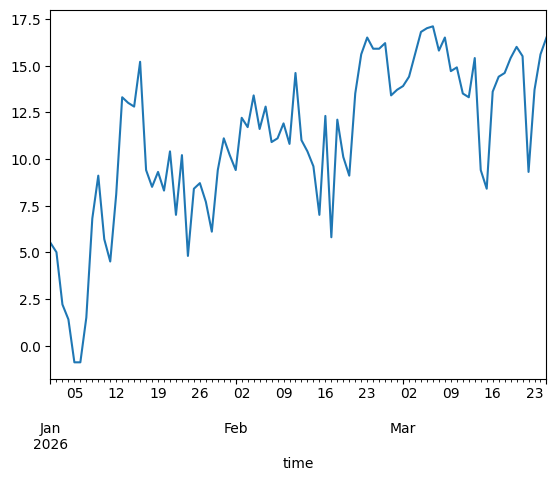

In [ ]:
# Graph
archives_meteo.temperature_2m_max.plot.line(x="time")
plt.show()


<Axes: xlabel='time'>

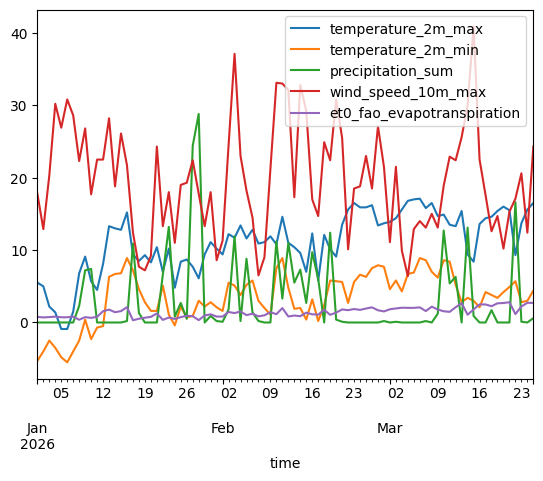

In [ ]:
archives_meteo.plot()

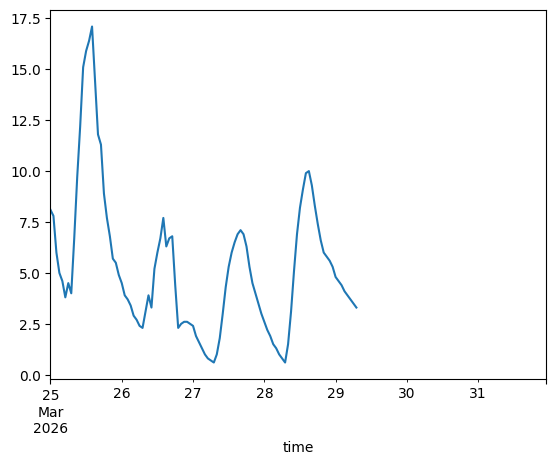

In [ ]:
# Données prévisionnelles
meteo_forecast = pd.DataFrame(forecast_data["hourly"])
meteo_forecast["time"] = pd.to_datetime(meteo_forecast["time"])
meteo_forecast.set_index("time", inplace=True)

meteo_forecast.temperature_2m.plot.line(x="time")
plt.show()


<Axes: xlabel='time'>

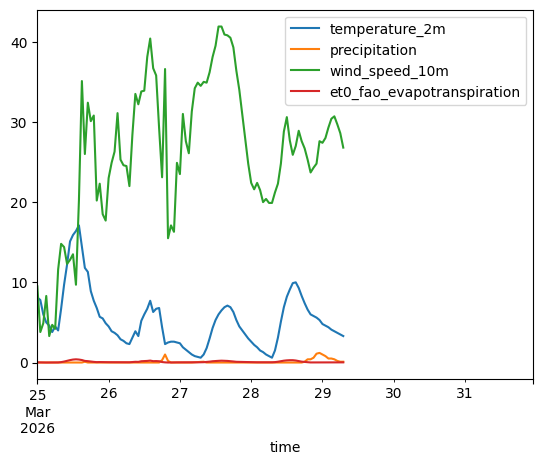

In [ ]:
meteo_forecast.plot()

# Créer des indicateurs à partir des données météo

In [ ]:
# Setup des valeurs seuils (à ajuster avec la biblio)
pluie = 0 # Valeur de la pluie au dela de laquelle on considère qu'il n'y a pas de dispersion
vent_max = 11 # Vitesse du vent au dela de laquelle il est interdit de pulveriser (donc risque = 0)
vent_dispersion = 4  # Vitesse du vent au dela de laquelle on considère qu'il y a un risque de dispersion

In [ ]:
archives_meteo.head()

,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,et0_fao_evapotranspiration,Interdiction_pulv
time,,,,,,
2026-01-01,5.5,-5.3,0.0,17.8,0.77,True
2026-01-02,5.0,-4.0,0.0,12.9,0.70,True
2026-01-03,2.2,-2.5,0.0,20.3,0.75,True
2026-01-04,1.4,-3.5,0.0,30.2,0.81,True
2026-01-05,-0.9,-4.8,0.0,26.9,0.72,True


In [ ]:
# Calcul des indicateurs météo
archives_meteo["Interdiction_pulv"] = archives_meteo["wind_speed_10m_max"] >= vent_max
archives_meteo["pluie_limitant_dispersion"] = archives_meteo["precipitation_sum"] >= pluie
archives_meteo["risque_dispersion"] = (archives_meteo["wind_speed_10m_max"] >= vent_dispersion) & (archives_meteo["wind_speed_10m_max"] < vent_max)

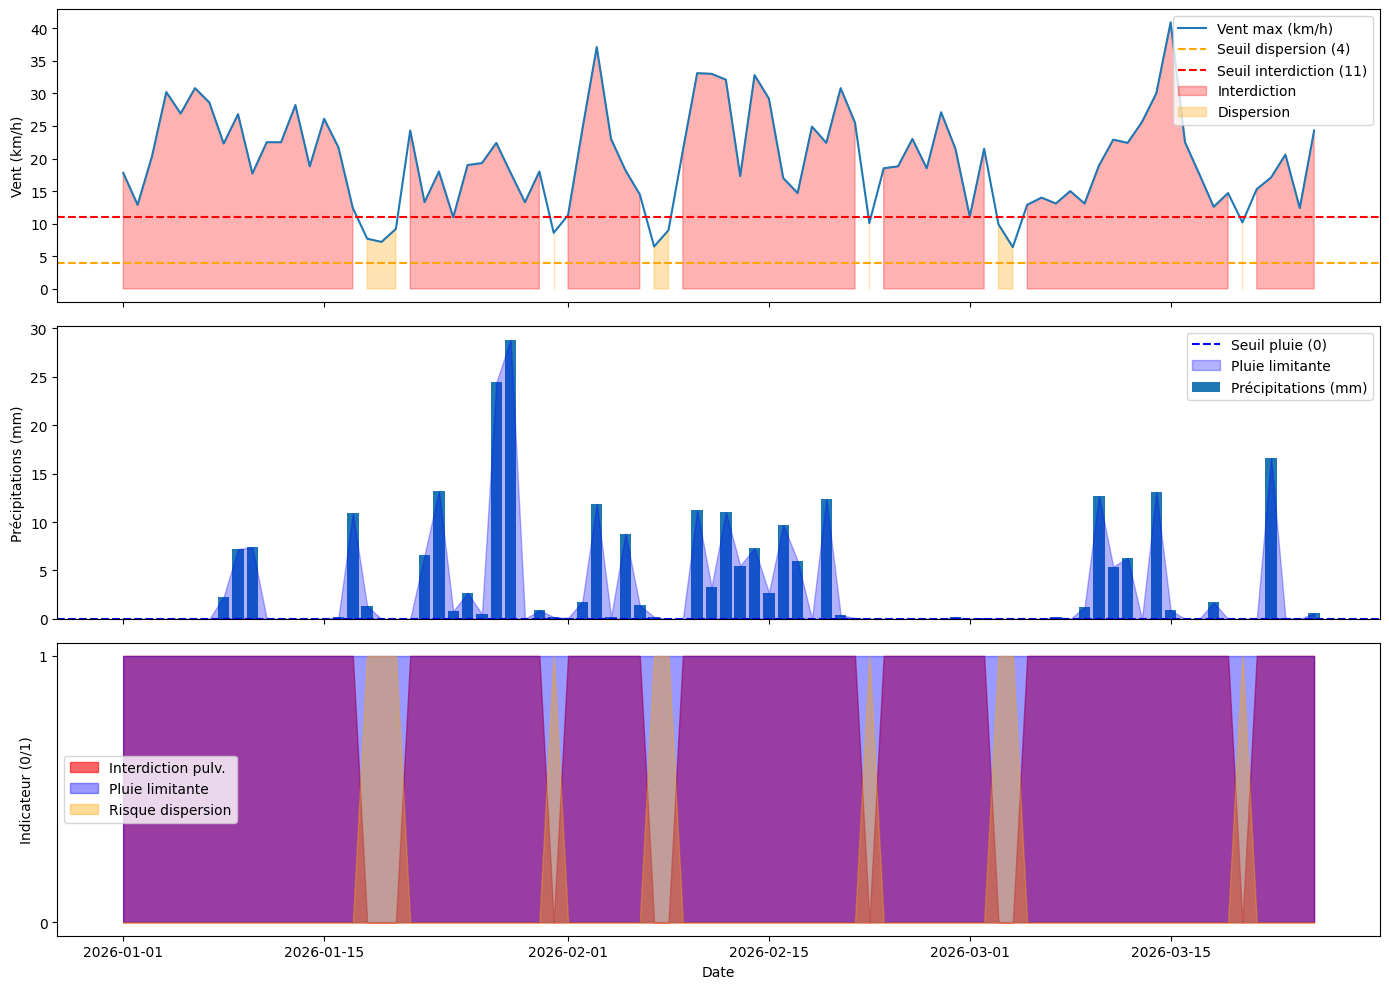

In [ ]:
# Verification graphique
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# 1. Vent + indicateurs associés
axes[0].plot(archives_meteo["wind_speed_10m_max"], label="Vent max (km/h)")
axes[0].axhline(vent_dispersion, color="orange", linestyle="--", label=f"Seuil dispersion ({vent_dispersion})")
axes[0].axhline(vent_max, color="red", linestyle="--", label=f"Seuil interdiction ({vent_max})")
axes[0].fill_between(archives_meteo.index, 0, archives_meteo["wind_speed_10m_max"],
                     where=archives_meteo["Interdiction_pulv"],  color="red",    alpha=0.3, label="Interdiction")
axes[0].fill_between(archives_meteo.index, 0, archives_meteo["wind_speed_10m_max"],
                     where=archives_meteo["risque_dispersion"],  color="orange", alpha=0.3, label="Dispersion")
axes[0].set_ylabel("Vent (km/h)")
axes[0].legend()

# 2. Précipitations + indicateur
axes[1].bar(archives_meteo.index, archives_meteo["precipitation_sum"], label="Précipitations (mm)")
axes[1].axhline(pluie, color="blue", linestyle="--", label=f"Seuil pluie ({pluie})")
axes[1].fill_between(archives_meteo.index, 0, archives_meteo["precipitation_sum"],
                     where=archives_meteo["pluie_limitant_dispersion"], color="blue", alpha=0.3, label="Pluie limitante")
axes[1].set_ylabel("Précipitations (mm)")
axes[1].legend()

# 3. Synthèse des 3 indicateurs binaires
axes[2].fill_between(archives_meteo.index, 0, archives_meteo["Interdiction_pulv"].astype(int),
                     color="red",    alpha=0.6, label="Interdiction pulv.")
axes[2].fill_between(archives_meteo.index, 0, archives_meteo["pluie_limitant_dispersion"].astype(int),
                     color="blue",   alpha=0.4, label="Pluie limitante")
axes[2].fill_between(archives_meteo.index, 0, archives_meteo["risque_dispersion"].astype(int),
                     color="orange", alpha=0.4, label="Risque dispersion")
axes[2].set_ylabel("Indicateur (0/1)")
axes[2].set_yticks([0, 1])
axes[2].legend()

plt.xlabel("Date")
plt.tight_layout()
plt.show()

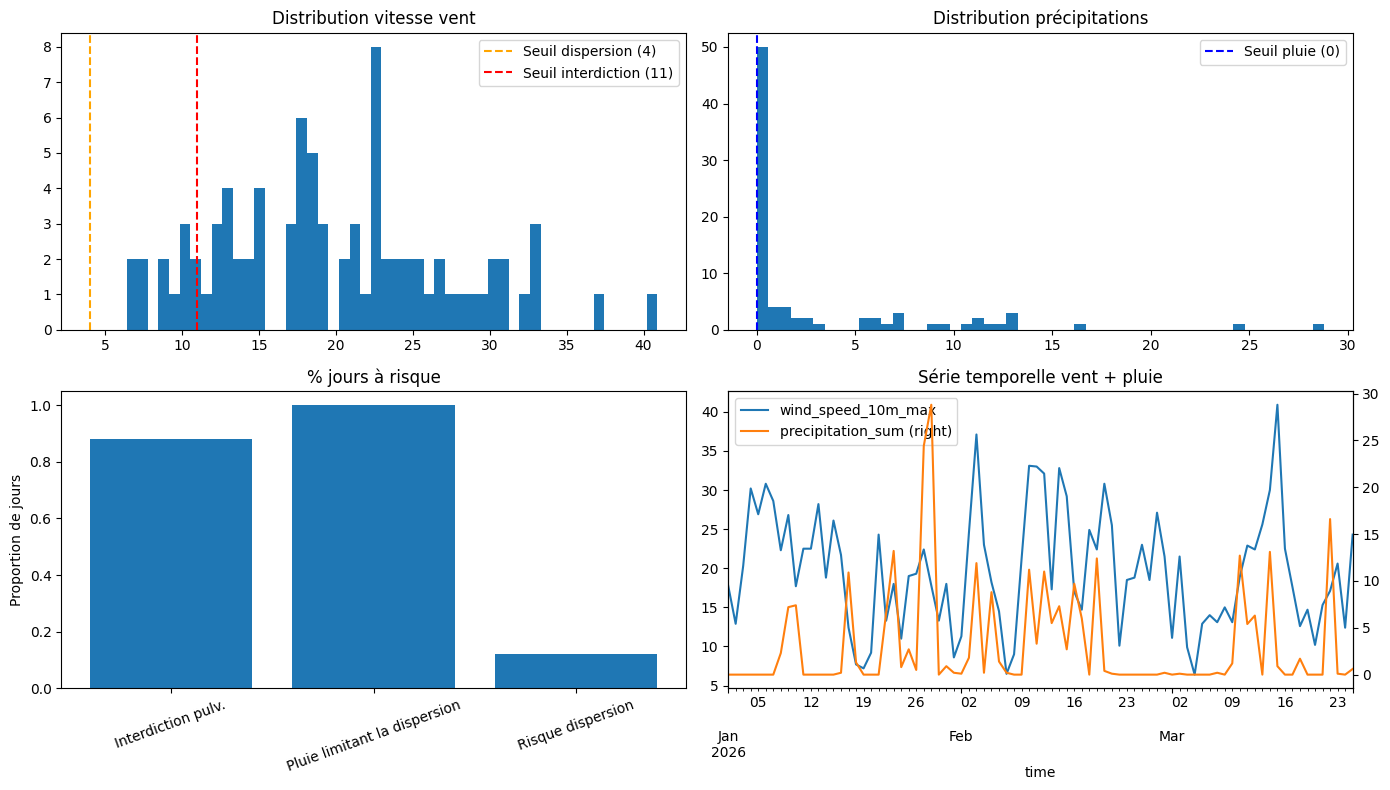

In [ ]:
# Représentation graphique
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Distribution du vent avec les seuils
axes[0, 0].hist(archives_meteo["wind_speed_10m_max"].dropna(), bins=50)
axes[0, 0].axvline(vent_dispersion, color="orange", linestyle="--", label=f"Seuil dispersion ({vent_dispersion})")
axes[0, 0].axvline(vent_max, color="red",    linestyle="--", label=f"Seuil interdiction ({vent_max})")
axes[0, 0].set_title("Distribution vitesse vent")
axes[0, 0].legend()

# 2. Distribution des précipitations avec seuil
axes[0, 1].hist(archives_meteo["precipitation_sum"].dropna(), bins=50)
axes[0, 1].axvline(pluie, color="blue", linestyle="--", label=f"Seuil pluie ({pluie})")
axes[0, 1].set_title("Distribution précipitations")
axes[0, 1].legend()

# 3. Proportion de jours par indicateur
props = {
    "Interdiction pulv.":     archives_meteo["Interdiction_pulv"].mean(),
    "Pluie limitant la dispersion":        archives_meteo["pluie_limitant_dispersion"].mean(),
    "Risque dispersion":      archives_meteo["risque_dispersion"].mean(),
}
axes[1, 0].bar(props.keys(), props.values())
axes[1, 0].set_ylabel("Proportion de jours")
axes[1, 0].set_title("% jours à risque")
axes[1, 0].tick_params(axis="x", rotation=20)

# 4. Série temporelle
archives_meteo[["wind_speed_10m_max", "precipitation_sum"]].plot(
    ax=axes[1, 1], secondary_y="precipitation_sum"
)
axes[1, 1].set_title("Série temporelle vent + pluie")

plt.tight_layout()
plt.show()